# PatchCore 工业异常检测实验 —— MVTec AD Bottle

## 实验目的

本实验使用 PatchCore 在 MVTec AD 数据集的 Bottle 类别上进行工业异常检测实验。

主要目标：

1. 理解工业异常检测的基本任务；
2. 理解 PatchCore 特征式异常检测的基本原理；
3. 使用正常样本建立正常特征 Memory Bank；
4. 对测试图片进行异常检测与定位；
5. 使用 AUROC、F1 等指标评价检测效果；
6. 可视化 Ground Truth、Anomaly Map 和 Predicted Mask。

## 实验流程

正常训练图片
→ CNN 提取局部特征
→ Coreset Sampling
→ Memory Bank
→ 测试图片特征
→ 最近邻特征比较
→ Anomaly Map
→ Predicted Mask

## 1. 实验环境与依赖

In [1]:
from pathlib import Path

import torch
import matplotlib.pyplot as plt

from anomalib.data import MVTecAD
from anomalib.models import Patchcore
from anomalib.engine import Engine

print("PyTorch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

W0925 21:43:21.846000 23912 site-packages\torch\utils\flop_counter.py:29] triton not found; flop counting will not work for triton kernels
d:\miniconda\envs\industrial-ad\Lib\site-packages\timm\models\layers\__init__.py:49: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)
d:\miniconda\envs\industrial-ad\Lib\site-packages\anomalib\models\image\dinomaly\components\layers.py:22: FutureWarning: The anomalib.models.components.dinov2 package is deprecated and will be removed in a future release. Please use the timm-based feature extractor instead: anomalib.models.components.feature_extractors.TimmFeatureExtractor
  from anomalib.models.components.dinov2.layers import Attention, DropPath, LayerScale, MemEffAttention


PyTorch: 2.11.0+cu128
CUDA available: True
GPU: NVIDIA GeForce RTX 5060 Laptop GPU


## 2. 数据集：MVTec AD Bottle

本实验使用 MVTec AD 工业异常检测数据集中的 **Bottle** 类别。

PatchCore 采用无监督异常检测思路：

- **训练集**：仅包含正常（Good）样本，用于建立正常特征 Memory Bank；
- **测试集**：同时包含正常样本和不同类型的异常样本；
- **Ground Truth**：提供异常区域的像素级标注，用于评价模型的异常定位能力。

本实验首先使用 Bottle 类别完成 PatchCore Baseline 复现。

In [2]:
from anomalib.data import MVTecAD

datamodule = MVTecAD(
    root="../data/mvtec_ad",
    category="bottle",
    train_batch_size=16,
    eval_batch_size=16,
    num_workers=0,
)

datamodule.setup()

print("Bottle 数据加载成功！")
print("训练图片：", len(datamodule.train_data))
print("测试图片：", len(datamodule.test_data))

Bottle 数据加载成功！
训练图片： 209
测试图片： 83


## 3. PatchCore 模型

本实验使用 PatchCore 作为异常检测 Baseline。

主要配置：

- **Backbone：Wide ResNet-50-2**
  - 使用预训练 CNN 提取图像特征；
  - PatchCore 本身不需要从头训练一个分类网络。

- **特征层：layer2 + layer3**
  - 从 CNN 的中间层提取局部视觉特征；
  - 不同层包含不同尺度的图像信息。

- **Coreset Sampling Ratio：0.1**
  - 不保存所有正常 Patch 特征；
  - 从全部特征中选择约 10% 的代表性特征；
  - 在尽量保留正常特征分布的同时减少 Memory Bank 大小和计算量。

In [3]:
model = Patchcore(
    backbone="wide_resnet50_2",
    layers=["layer2", "layer3"],
    coreset_sampling_ratio=0.1,
)

print("PatchCore 模型创建成功！")
print("Backbone: wide_resnet50_2")
print("Feature layers: layer2 + layer3")
print("Coreset sampling ratio: 0.1")

PatchCore 模型创建成功！
Backbone: wide_resnet50_2
Feature layers: layer2 + layer3
Coreset sampling ratio: 0.1


## 4. 创建实验 Engine

Anomalib 的 `Engine` 用于统一管理模型的拟合、测试和预测流程。

本实验关闭额外日志记录和进度条，以减少 Notebook 中不必要的输出。

In [4]:
engine = Engine(
    enable_progress_bar=False,
    logger=False,
)

print("Engine 创建成功！")

Engine 创建成功！


## 5. Fit：建立正常特征 Memory Bank

PatchCore 的 `fit` 与普通分类网络的训练有所不同。

本实验中：

1. 将 209 张正常 Bottle 图片输入预训练 CNN；
2. 从 `layer2` 和 `layer3` 提取局部 Patch 特征；
3. 汇总正常样本的特征；
4. 使用 Coreset Sampling 选择约 10% 的代表性特征；
5. 将这些特征保存为正常样本的 Memory Bank。

后续检测异常图片时，会将测试图片的局部特征与 Memory Bank 中的正常特征进行比较。

In [5]:
engine.fit(
    model=model,
    datamodule=datamodule,
)

print("PatchCore 拟合完成！")

Exception in thread Thread-3 (_readerthread):
Traceback (most recent call last):
  File "d:\miniconda\envs\industrial-ad\Lib\threading.py", line 1045, in _bootstrap_inner
    self.run()
  File "d:\miniconda\envs\industrial-ad\Lib\threading.py", line 982, in run
    self._target(*self._args, **self._kwargs)
  File "d:\miniconda\envs\industrial-ad\Lib\subprocess.py", line 1599, in _readerthread
    buffer.append(fh.read())
                  ^^^^^^^^^
  File "<frozen codecs>", line 322, in decode
UnicodeDecodeError: 'utf-8' codec can't decode byte 0xb4 in position 235: invalid start byte
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
You are using a CUDA device ('NVIDIA GeForce RTX 5060 Laptop GPU') that has Tensor Cores. To prope

┏━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name           ┃ Type           ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ pre_processor  │ PreProcessor   │      0 │ train │     0 │
│ 1 │ post_processor │ PostProcessor  │      0 │ train │     0 │
│ 2 │ evaluator      │ Evaluator      │      0 │ train │     0 │
│ 3 │ model          │ PatchcoreModel │ 24.9 M │ train │     0 │
└───┴────────────────┴────────────────┴────────┴───────┴───────┘

Trainable params: 24.9 M                                                                                           
Non-trainable params: 0                                                                                            
Total params: 24.9 M                                                                                               
Total estimated model params size (MB): 99.450                                                                     
Modules in train mode: 19                                                                                          
Modules in eval mode: 174                                                                                          
Total FLOPs: 0

d:\miniconda\envs\industrial-ad\Lib\site-packages\lightning\pytorch\utilities\_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
d:\miniconda\envs\industrial-ad\Lib\site-packages\lightning\pytorch\trainer\connectors\data_connector.py:434: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=13` in the `DataLoader` to improve performance.
d:\miniconda\envs\industrial-ad\Lib\site-packages\lightning\pytorch\trainer\connectors\data_connector.py:434: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=13` in the `DataLoader` to improve performance.
d:\miniconda\envs\industrial-ad\Lib\site-packages\lightning\pytorch\loops\fit_loop.py:538: Found 174 module(s) in eval mode at the start of training. This may lead to u

PatchCore 拟合完成！


## 6. Test：模型性能评估

完成 Memory Bank 构建后，在 Bottle 测试集上评价 PatchCore 的异常检测与定位能力。

本实验主要关注两类指标：

- **Image AUROC / Image F1**
  - 图像级指标；
  - 判断整张图片是正常还是异常。

- **Pixel AUROC / Pixel F1**
  - 像素级指标；
  - 判断图片中的哪些区域属于异常。

因此，图像级指标主要反映“能不能发现这张图片有问题”，
像素级指标主要反映“能不能准确找到问题发生在哪里”。

In [6]:
test_results = engine.test(
    model=model,
    datamodule=datamodule,
)

print("PatchCore 测试完成！")

The following callbacks returned in `LightningModule.configure_callbacks` will override existing callbacks passed to Trainer: Evaluator, ImageVisualizer, PostProcessor, PreProcessor
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
d:\miniconda\envs\industrial-ad\Lib\site-packages\lightning\pytorch\trainer\connectors\data_connector.py:434: The 'test_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=13` in the `DataLoader` to improve performance.


┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃        Test metric        ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│        image_AUROC        │            1.0            │
│       image_F1Score       │    0.9919999837875366     │
│        pixel_AUROC        │    0.9855899810791016     │
│       pixel_F1Score       │    0.7263164520263672     │
└───────────────────────────┴───────────────────────────┘

PatchCore 测试完成！


## 7. Predict：生成异常检测结果

`Test` 用于计算整个测试集的评价指标，而 `Predict` 用于获得每张测试图片的具体预测结果。

预测结果主要包括：

- `anomaly_map`：连续的像素级异常分数，用于生成异常热力图；
- `pred_mask`：根据异常阈值得到的二值预测区域；
- `pred_score`：图像级异常分数；
- `pred_label`：图像级正常 / 异常判断。

后续将从预测结果中选择一个 `broken_large` 异常样本进行可视化分析。

In [7]:
predictions = engine.predict(
    model=model,
    datamodule=datamodule,
)

print("预测完成！")
print("返回的 batch 数量：", len(predictions))
print("第一个 batch 类型：", type(predictions[0]))

ckpt_path is not provided. Model weights will not be loaded.
The following callbacks returned in `LightningModule.configure_callbacks` will override existing callbacks passed to Trainer: Evaluator, ImageVisualizer, PostProcessor, PreProcessor
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
d:\miniconda\envs\industrial-ad\Lib\site-packages\lightning\pytorch\trainer\connectors\data_connector.py:434: The 'predict_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=13` in the `DataLoader` to improve performance.


预测完成！
返回的 batch 数量： 6
第一个 batch 类型： <class 'anomalib.data.dataclasses.torch.image.ImageBatch'>


### 选择 broken_large 异常样本

为了直观观察 PatchCore 的异常定位效果，
从预测结果中选择一个 `broken_large` 样本，
比较真实缺陷区域与模型预测结果。

In [8]:
target = None
target_index = None

for batch in predictions:
    for i, path in enumerate(batch.image_path):
        if "broken_large" in str(path):
            target = batch
            target_index = i

            print("找到异常图片：", path)
            print("预测异常分数：", batch.pred_score[i].item())
            print("预测标签：", batch.pred_label[i].item())
            break

    if target is not None:
        break

找到异常图片： D:\Research\research-experiments\industrial-anomaly-detection\data\mvtec_ad\bottle/test/broken_large/000.png
预测异常分数： 0.9372506141662598
预测标签： True


## 8. 异常检测结果可视化

选择一个 `broken_large` 异常样本，对 PatchCore 的检测结果进行可视化。

从左到右分别展示：

1. **Original Image**：原始 Bottle 图像；
2. **Ground Truth**：数据集提供的真实缺陷区域；
3. **PatchCore Anomaly Map**：模型输出的连续异常分数热力图，颜色越偏红表示异常程度越高；
4. **Predicted Mask**：根据异常阈值得到的二值预测区域。

通过 Ground Truth、Anomaly Map 和 Predicted Mask 的对比，可以直观观察模型是否正确定位到实际缺陷区域。

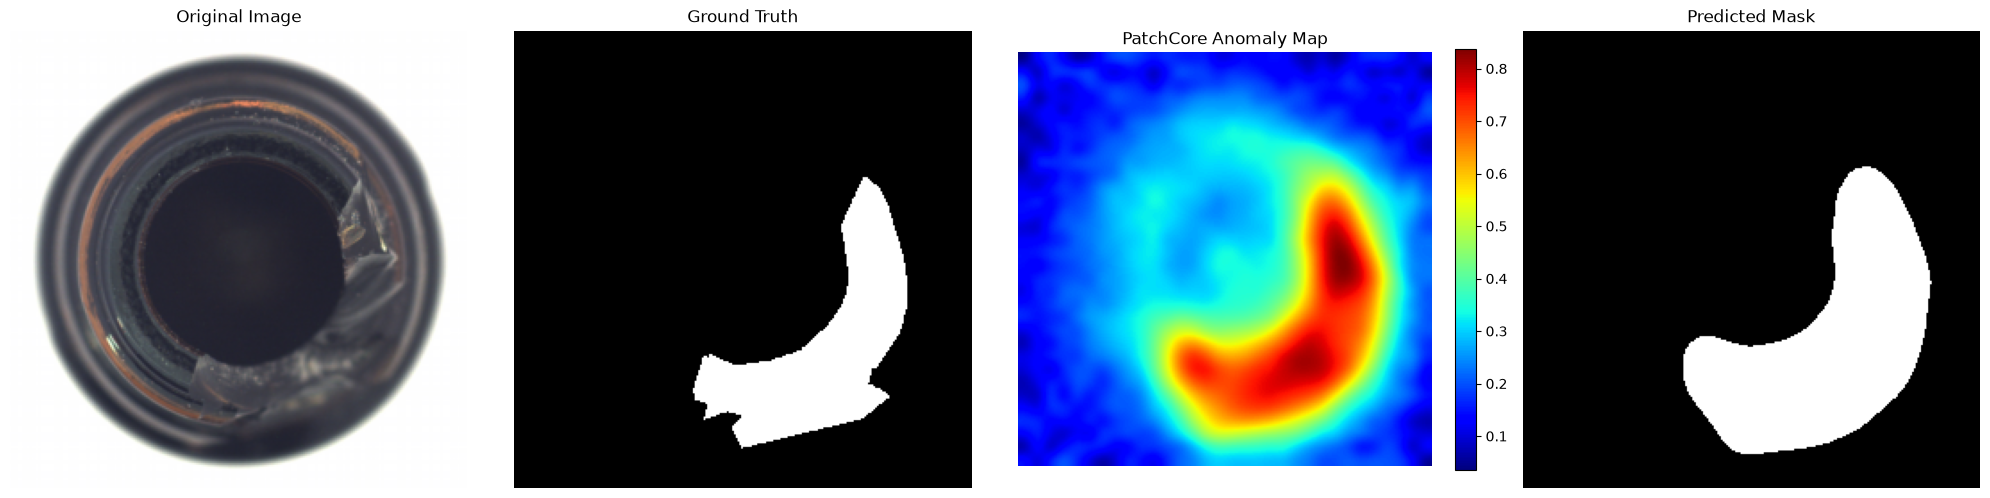

In [9]:
import torch
from pathlib import Path
import matplotlib.pyplot as plt

Path("../results").mkdir(parents=True, exist_ok=True)

# 取出这一张图片的四种信息
img = target.image[target_index].detach().cpu()
gt_mask = target.gt_mask[target_index].detach().cpu()
anomaly_map = target.anomaly_map[target_index].detach().cpu()
pred_mask = target.pred_mask[target_index].detach().cpu()

# ImageNet 标准化使用的 mean 和 std
mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)

# 反归一化：恢复原来的 RGB 像素
img = img * std + mean

# 限制到 matplotlib 正常显示的 [0, 1]
img = img.clamp(0, 1)

# [C, H, W] → [H, W, C]
img = img.permute(1, 2, 0)

gt_mask = gt_mask.squeeze()
anomaly_map = anomaly_map.squeeze()
pred_mask = pred_mask.squeeze()

fig, axes = plt.subplots(1, 4, figsize=(20, 5))

axes[0].imshow(img)
axes[0].set_title("Original Image")

axes[1].imshow(gt_mask, cmap="gray")
axes[1].set_title("Ground Truth")

heatmap = axes[2].imshow(anomaly_map, cmap="jet")
axes[2].set_title("PatchCore Anomaly Map")
plt.colorbar(heatmap, ax=axes[2], fraction=0.046)

axes[3].imshow(pred_mask, cmap="gray")
axes[3].set_title("Predicted Mask")

for ax in axes:
    ax.axis("off")

plt.tight_layout()

plt.savefig(
    "../results/patchcore_bottle_broken_large.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## 9. 实验结果与总结

### 实验结果

本实验成功在 MVTec AD Bottle 数据集上完成了 PatchCore Baseline 的搭建与运行。

模型仅使用正常样本建立 Memory Bank，并通过比较测试样本局部特征与正常特征之间的差异实现异常检测。

从测试结果和可视化结果可以观察到：

- PatchCore 能够有效区分正常与异常 Bottle 图像；
- Anomaly Map 的高响应区域与真实缺陷区域基本一致；
- Predicted Mask 能够定位主要缺陷区域；
- 图像级检测效果较好，但像素级预测区域与 Ground Truth 仍存在一定边界差异。

### 本次实验理解

通过本实验，初步理解了 PatchCore 的基本流程：

**正常样本 → 特征提取 → Coreset Sampling → Memory Bank → 特征距离比较 → Anomaly Map → 异常判定**

与传统监督目标检测不同，PatchCore 不需要收集大量不同类型的缺陷样本，而是通过学习正常样本的特征分布来发现异常。

### 下一步

1. 记录并分析 Image-level 与 Pixel-level 评价指标；
2. 尝试其他 MVTec AD 类别，验证 PatchCore 的泛化表现；
3. 对比不同 `coreset_sampling_ratio` 对精度、速度和 Memory Bank 大小的影响；
4. 后续尝试其他工业异常检测 Baseline，与 PatchCore 进行对比。